In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
# Step 1: Data Collection
def fetch_stock_data(ticker, start, end):
    stock_data = yf.download(ticker, start=start, end=end)
    return stock_data[['Close']]

# Fetch historical stock data
stock_data = fetch_stock_data('GOOGL', '2012-01-01', '2022-12-31')

# Step 2: Data Preprocessing
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(stock_data)



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
# Step 3: Creating training sequences
def create_sequences(data, time_step=60):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

X, Y = create_sequences(scaled_data)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))




In [ ]:
# Split data into training and testing
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]



In [ ]:
# Step 4: Building LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, Y_train, batch_size=16, epochs=20, validation_data=(X_test, Y_test))



Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0057 - val_loss: 0.0018
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 5.5798e-04 - val_loss: 0.0012
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 4.8062e-04 - val_loss: 0.0011
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 3.0017e-04 - val_loss: 0.0014
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 2.5939e-04 - val_loss: 0.0024
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 2.7299e-04 - val_loss: 0.0023
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 2.4886e-04 - val_loss: 0.0049
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 2.5765e-04 - val_loss: 0.0010
Epoch 9/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 2.1210e-04 - val_loss: 0.0026
Epoch 10/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 2.7710e-04 - val_loss: 0.0031
Epoch 11/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 2.6914e-04 - val_loss: 7.7666e-04
Epo

In [ ]:
# Step 5: Making Predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))

# Step 6: Sentiment Analysis
def get_sentiment_score(news):
    sia = SentimentIntensityAnalyzer()
    return sia.polarity_scores(news)['compound']

# Example News Data
news_data = [
    "Google's stock is expected to rise due to strong quarterly earnings.",
    "Investors are worried about a potential economic downturn affecting tech stocks.",
    "Google announces major innovations in AI technology."
]

sentiment_scores = [get_sentiment_score(news) for news in news_data]
print("Sentiment Scores:", sentiment_scores)



17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Sentiment Scores: [0.5106, -0.296, 0.0]


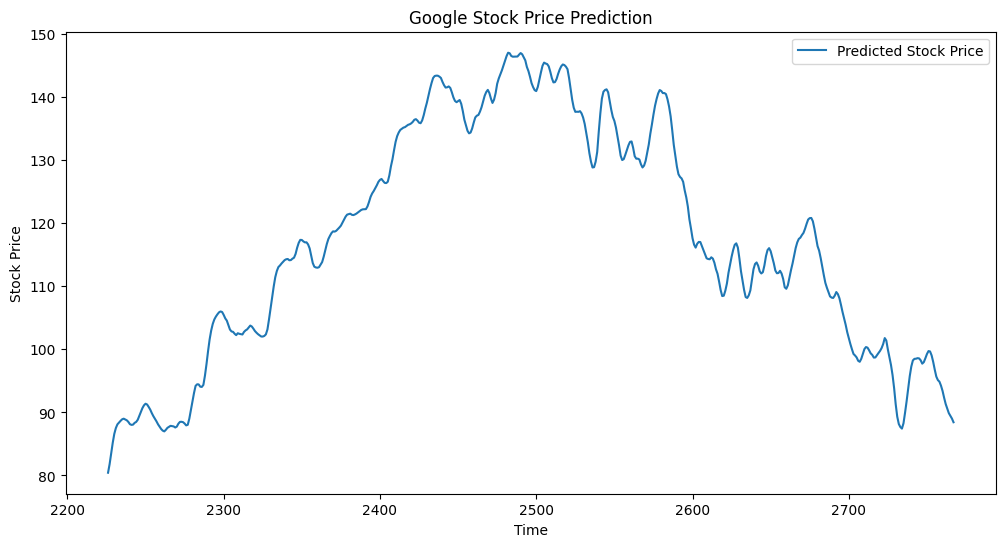

In [ ]:
# Step 7: Visualization
plt.figure(figsize=(12,6))
#sns.lineplot(data=stock_data, label='Actual Stock Price')
sns.lineplot(x=range(len(stock_data)-len(predictions), len(stock_data)), y=predictions.flatten(), label='Predicted Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [ ]:
# Comparison with Linear Regression and Random Forest
X_train_lr, X_test_lr = X_train.reshape(X_train.shape[0], -1), X_test.reshape(X_test.shape[0], -1)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, Y_train)
lr_predictions = lr_model.predict(X_test_lr)
lr_predictions = scaler.inverse_transform(lr_predictions.reshape(-1, 1))


In [ ]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_lr, Y_train)
rf_predictions = rf_model.predict(X_test_lr)
rf_predictions = scaler.inverse_transform(rf_predictions.reshape(-1, 1))

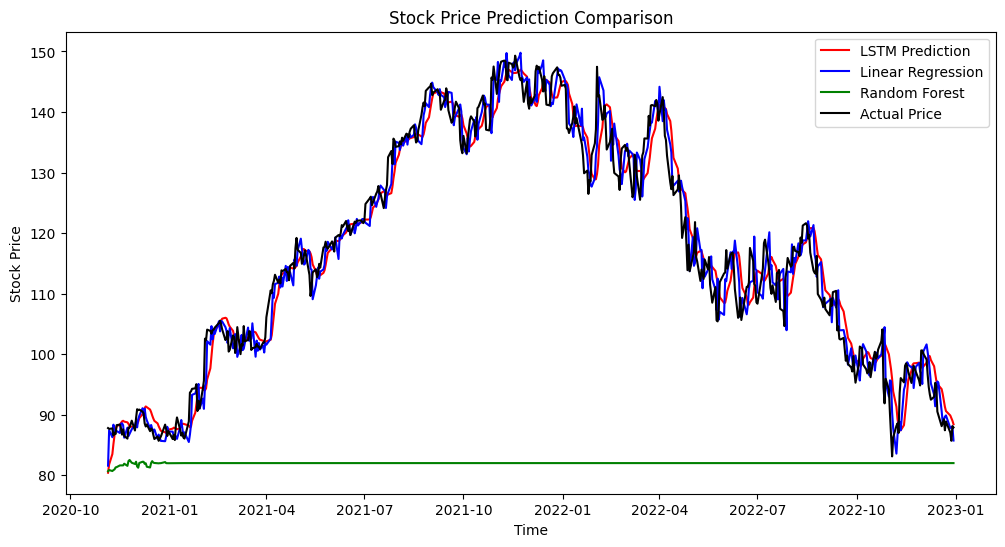

In [ ]:
# Ensure correct index alignment for predictions
test_index = stock_data.index[-len(Y_test):]

plt.figure(figsize=(12,6))
# Assign LSTM model predictions to lstm_predictions
lstm_predictions = predictions
plt.plot(test_index, lstm_predictions[:len(test_index)], label='LSTM Prediction', color='red')
plt.plot(test_index, lr_predictions[:len(test_index)], label='Linear Regression', color='blue')
plt.plot(test_index, rf_predictions[:len(test_index)], label='Random Forest', color='green')
plt.plot(test_index, stock_data['Close'].iloc[-len(test_index):], label='Actual Price', color='black')
plt.title('Stock Price Prediction Comparison')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

